# AIML Lab 7 - Medical Reviews Analysis from Social Media Data

Dataset: `medical_reviews.csv`, a balanced sample of 3600 patient reviews from Drugs.com.
The 1 to 10 star rating was mapped to a sentiment label (>= 8 Positive, <= 4 Negative, 5 to 7 Neutral).

## Part A - Import and Explore Medical Review Data

In [1]:
import re
import html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

nltk.download("stopwords", quiet=True)
nltk.download("punkt_tab", quiet=True)
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("medical_reviews.csv")
print("Dataset Imported Successfully.")
df.head()

Dataset Imported Successfully.


,Review,Condition,Rating,Sentiment
0,I&#039;ve been on geodon for about three weeks...,Schizophrenia,7.0,Neutral
1,It was given to my 91 yr. old mother 3 times a...,Peripheral Neuropathy,7.0,Neutral
2,Incredible. I was on Adderall for over a year...,ADHD,10.0,Positive
3,11 weeks pregnant and took this for a sinus in...,Chlamydia Infection,8.0,Positive
4,Impossible to open. Don&#039;t buy it.,Nasal Congestion,1.0,Negative


In [3]:
print("Number of Medical Reviews:", df.shape[0])
print("Number of Features:", df.shape[1])
print("Columns:", list(df.columns))

Number of Medical Reviews: 3600
Number of Features: 4
Columns: ['Review', 'Condition', 'Rating', 'Sentiment']


In [4]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Review        0
Condition    19
Rating        0
Sentiment     0
dtype: int64


In [5]:
counts = df["Sentiment"].value_counts()

print("Sentiment Class Distribution:")
print("Positive :", counts["Positive"])
print("Negative :", counts["Negative"])
print("Neutral  :", counts["Neutral"])

Sentiment Class Distribution:
Positive : 1200
Negative : 1200
Neutral  : 1200


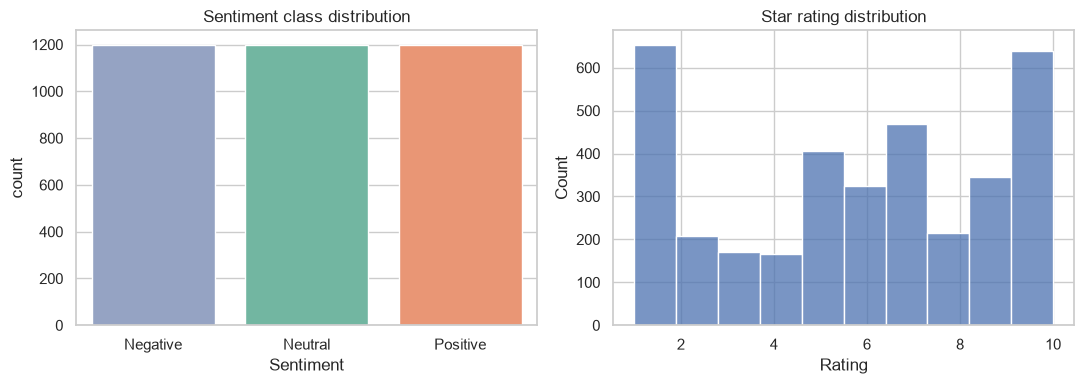

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(x="Sentiment", data=df, order=["Negative", "Neutral", "Positive"],
              hue="Sentiment", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Sentiment class distribution")

sns.histplot(df["Rating"], bins=10, ax=axes[1])
axes[1].set_title("Star rating distribution")

plt.tight_layout()
plt.show()

In [7]:
print("Most reviewed conditions:")
print(df["Condition"].value_counts().head(10).to_string())

Most reviewed conditions:
Condition
Birth Control      767
Depression         213
Acne               121
Pain               111
Anxiety            109
Insomnia            90
ADHD                84
Bipolar Disorde     82
Obesity             73
Weight Loss         70


In [8]:
reviews = df["Review"]
labels = df["Sentiment"]
print(reviews.shape, labels.shape)

(3600,) (3600,)


## Part B - Text Preprocessing

In [9]:
before = len(df)
df = df.dropna(subset=["Review"])
df = df[df["Review"].str.strip() != ""]
removed = before - len(df)

print("TEXT PREPROCESSING")
print("-" * 40)
print("Missing Reviews Removed:", removed)
print("Reviews remaining:", len(df))

TEXT PREPROCESSING
----------------------------------------
Missing Reviews Removed: 0
Reviews remaining: 3600


In [10]:
stop_words = set(stopwords.words("english"))
# negations are kept, dropping them would flip the meaning of a review
stop_words -= {"not", "no", "nor", "never", "against", "don't", "doesn't", "didn't", "won't"}


def clean_text(text):
    text = html.unescape(text)             # the reviews contain &#039; and &amp;
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)
    return " ".join(t for t in tokens if t not in stop_words and len(t) > 1)

In [11]:
demo = "The doctor was AMAZING!!! Visit https://hospital.com @patient #GoodHospital"
print("Original:", demo)
print("Cleaned :", clean_text(demo))

Original: The doctor was AMAZING!!! Visit https://hospital.com @patient #GoodHospital
Cleaned : doctor amazing visit goodhospital


In [12]:
df["Cleaned_Review"] = df["Review"].apply(clean_text)
df = df[df["Cleaned_Review"] != ""]

for i in [0, 5, 12]:
    print("Original Review:")
    print(df["Review"].iloc[i][:220])
    print()
    print("Cleaned Review:")
    print(df["Cleaned_Review"].iloc[i][:220])
    print("-" * 60)

print("Text Preprocessing Completed Successfully.")

Original Review:
I&#039;ve been on geodon for about three weeks now. So far no side effects but it&#039;s diffcult to take with 500 calorie meals. I&#039;m not much of a breakfast gal and find myself looking for food to take my medicine 

Cleaned Review:
've geodon three weeks far no side effects 's diffcult take calorie meals 'm not much breakfast gal find looking food take medicine morning
------------------------------------------------------------
Original Review:
I am only on Plaquenil a month now for primary Sjogren&#039;s Syndrome having been diagnosed in Jan 2014.  So far I am feeling much better in that I am sleeping so much better.  Before taking medication I would wake 5/6 

Cleaned Review:
plaquenil month primary sjogren 's syndrome diagnosed jan far feeling much better sleeping much better taking medication would wake times night found difficult go back sleep wake go back almost immediately first thing no
------------------------------------------------------------
Origina

In [13]:
df["word_count"] = df["Cleaned_Review"].str.split().str.len()
print(df["word_count"].describe().round(1).to_string())
df[["Review", "Cleaned_Review", "Sentiment"]].head()

count    3600.0
mean       42.6
std        21.8
min         1.0
25%        24.0
50%        43.0
75%        62.0
max       103.0


,Review,Cleaned_Review,Sentiment
0,I&#039;ve been on geodon for about three weeks...,'ve geodon three weeks far no side effects 's ...,Neutral
1,It was given to my 91 yr. old mother 3 times a...,given yr old mother times day nerve damage fee...,Neutral
2,Incredible. I was on Adderall for over a year...,incredible adderall year doctor switched vyvan...,Positive
3,11 weeks pregnant and took this for a sinus in...,weeks pregnant took sinus infection mg days st...,Positive
4,Impossible to open. Don&#039;t buy it.,impossible open n't buy,Negative


## Part C - TF-IDF Feature Extraction

In [14]:
X = df["Cleaned_Review"]
y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)     # fitted on the training data only
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF FEATURE EXTRACTION")
print("-" * 40)
print("Training Reviews:", X_train.shape[0])
print("Testing Reviews :", X_test.shape[0])
print()
print("Number of TF-IDF Features:", len(tfidf.get_feature_names_out()))
print()
print("Training Matrix Shape:", X_train_tfidf.shape)
print("Testing Matrix Shape :", X_test_tfidf.shape)
print()
print("TF-IDF Feature Extraction Completed.")

TF-IDF FEATURE EXTRACTION
----------------------------------------
Training Reviews: 2880
Testing Reviews : 720

Number of TF-IDF Features: 5000

Training Matrix Shape: (2880, 5000)
Testing Matrix Shape : (720, 5000)

TF-IDF Feature Extraction Completed.


In [15]:
feature_names = tfidf.get_feature_names_out()
print("Sample unigrams:", [f for f in feature_names if " " not in f][:15])
print()
print("Sample bigrams :", [f for f in feature_names if " " in f][:15])

Sample unigrams: ['abdomen', 'abdominal', 'abilify', 'ability', 'ablation', 'able', 'abnormal', 'absolute', 'absolutely', 'abuse', 'accident', 'accutane', 'ache', 'aches', 'aching']

Sample bigrams : ['abdominal pain', 'able control', 'able get', 'able go', 'able sleep', 'able take', 'abnormal bleeding', 'absolutely love', 'absolutely no', 'absolutely nothing', 'acne bad', 'acne cleared', 'acne face', 'acne gotten', 'acne mood']


## Part D - Train and Compare Classification Models

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Multinomial Naive Bayes": MultinomialNB(),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = {}

print("MODEL COMPARISON")
print("-" * 40)
for name, model in models.items():
    scores = cross_validate(model, X_train_tfidf, y_train, cv=cv,
                            scoring=["accuracy", "f1_macro"])
    cv_scores[name] = scores
    print()
    print(name)
    print(f"Mean CV Accuracy : {scores['test_accuracy'].mean():.4f}")
    print(f"Mean CV F1-Score : {scores['test_f1_macro'].mean():.4f}")

best_name = max(cv_scores, key=lambda n: cv_scores[n]["test_f1_macro"].mean())
print()
print("Selected Model:", best_name)

MODEL COMPARISON
----------------------------------------



Logistic Regression
Mean CV Accuracy : 0.5747
Mean CV F1-Score : 0.5736

Multinomial Naive Bayes
Mean CV Accuracy : 0.5642
Mean CV F1-Score : 0.5637

Selected Model: Logistic Regression


In [17]:
for model in models.values():
    model.fit(X_train_tfidf, y_train)

best_model = models[best_name]

## Part E - Predict Sentiment of a New Medical Review

In [18]:
new_review = ("The doctor explained the treatment clearly and the hospital staff "
              "were very supportive.")

cleaned = clean_text(new_review)
vector = tfidf.transform([cleaned])
prediction = best_model.predict(vector)[0]
probs = best_model.predict_proba(vector)[0]

print("NEW MEDICAL REVIEW CLASSIFICATION")
print("-" * 40)
print("Review:")
print(new_review)
print()
print("Cleaned:", cleaned)
print()
print("Predicted Sentiment:", prediction)
print()
print("Class Probabilities:")
for cls, p in zip(best_model.classes_, probs):
    print(f"{cls:<9}: {p:.4f}")

NEW MEDICAL REVIEW CLASSIFICATION
----------------------------------------
Review:
The doctor explained the treatment clearly and the hospital staff were very supportive.

Cleaned: doctor explained treatment clearly hospital staff supportive

Predicted Sentiment: Positive

Class Probabilities:
Negative : 0.3959
Neutral  : 0.2065
Positive : 0.3976


In [19]:
# a review written in the same style as the training data, for comparison
in_domain = ("This medication worked really well for me, my symptoms improved within a week "
             "and I had no side effects at all.")

vec = tfidf.transform([clean_text(in_domain)])
print("Review:", in_domain)
print()
print("Predicted Sentiment:", best_model.predict(vec)[0])
for cls, p in zip(best_model.classes_, best_model.predict_proba(vec)[0]):
    print(f"{cls:<9}: {p:.4f}")

Review: This medication worked really well for me, my symptoms improved within a week and I had no side effects at all.

Predicted Sentiment: Positive
Negative : 0.1228
Neutral  : 0.1985
Positive : 0.6787


## Part F - Evaluate the Selected Model

In [20]:
y_pred = best_model.predict(X_test_tfidf)

print("FINAL MODEL EVALUATION")
print("-" * 40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred, average='macro'):.4f}")

FINAL MODEL EVALUATION
----------------------------------------
Accuracy  : 0.5556
Precision : 0.5508
Recall    : 0.5556
F1-Score  : 0.5521


In [21]:
print("CLASSIFICATION REPORT")
print("-" * 40)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
print("Confusion Matrix:")
print(cm)

CLASSIFICATION REPORT
----------------------------------------
              precision    recall  f1-score   support

    Negative       0.57      0.63      0.60       240
     Neutral       0.46      0.41      0.43       240
    Positive       0.61      0.63      0.62       240

    accuracy                           0.56       720
   macro avg       0.55      0.56      0.55       720
weighted avg       0.55      0.56      0.55       720

Confusion Matrix:
[[151  57  32]
 [ 79  98  63]
 [ 33  56 151]]


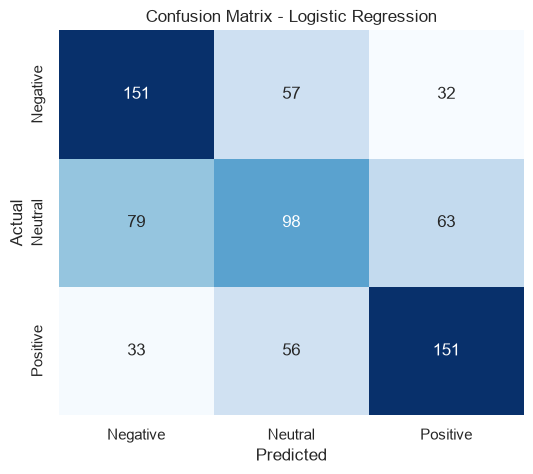

In [22]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
recalls = recall_score(y_test, y_pred, average=None, labels=best_model.classes_)
recall_by_class = pd.Series(recalls, index=best_model.classes_).round(4)

print(recall_by_class.to_string())
print()
print("Highest recall:", recall_by_class.idxmax(), f"({recall_by_class.max():.4f})")
print("Lowest recall :", recall_by_class.idxmin(), f"({recall_by_class.min():.4f})")

Negative    0.6292
Neutral     0.4083
Positive    0.6292

Highest recall: Negative (0.6292)
Lowest recall : Neutral (0.4083)


In [24]:
comparison = []
for name, model in models.items():
    p = model.predict(X_test_tfidf)
    comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, p),
        "Precision": precision_score(y_test, p, average="macro"),
        "Recall": recall_score(y_test, p, average="macro"),
        "F1-Score": f1_score(y_test, p, average="macro"),
    })

pd.DataFrame(comparison).set_index("Model").round(4)

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.5556,0.5508,0.5556,0.5521
Multinomial Naive Bayes,0.5375,0.5391,0.5375,0.5378


## Part G - Analyse Important Words

In [25]:
lr = models["Logistic Regression"]

print("IMPORTANT FEATURES")
for idx, sentiment in enumerate(lr.classes_):
    top = np.argsort(lr.coef_[idx])[-10:][::-1]
    print()
    print(f"{sentiment} Sentiment:")
    for rank, j in enumerate(top, 1):
        print(f"{rank:>2}. {feature_names[j]:<22} {lr.coef_[idx][j]:.4f}")

IMPORTANT FEATURES

Negative Sentiment:
 1. worse                  2.0170
 2. not                    1.7675
 3. never                  1.6157
 4. horrible               1.5671
 5. worst                  1.3861
 6. nothing                1.2939
 7. not recommend          1.2930
 8. stop                   1.2625
 9. help                   1.1966
10. bleeding               1.1048

Neutral Sentiment:
 1. however                1.2771
 2. naproxen               1.0360
 3. also                   1.0207
 4. mg                     0.9556
 5. feel                   0.9534
 6. trouble                0.9426
 7. not sure               0.9406
 8. nuvaring               0.9358
 9. problem                0.9037
10. effective              0.8983

Positive Sentiment:
 1. love                   2.3612
 2. years                  2.0002
 3. works                  1.7028
 4. best                   1.5968
 5. without                1.5314
 6. life                   1.3578
 7. miracle                1.3426
 

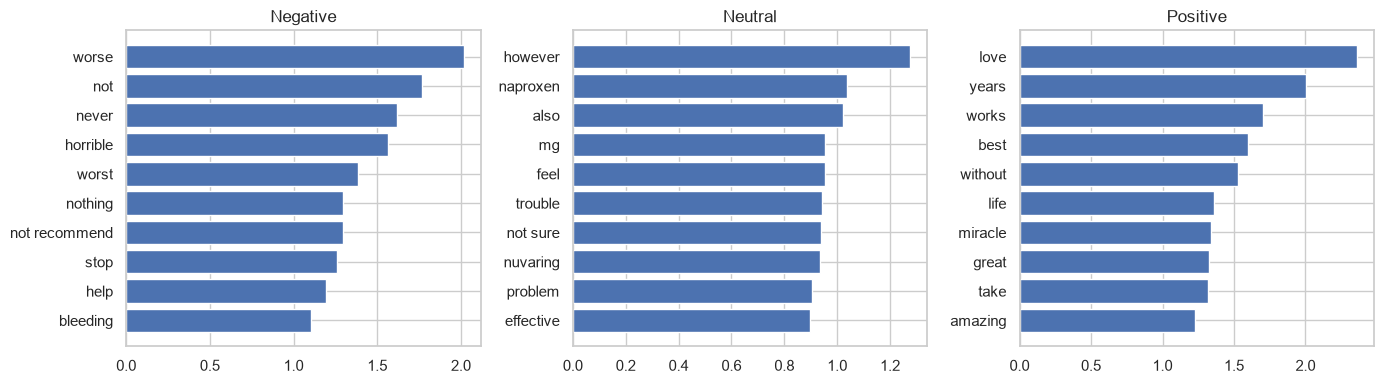

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, idx in zip(axes, range(len(lr.classes_))):
    top = np.argsort(lr.coef_[idx])[-10:]
    ax.barh([feature_names[j] for j in top], lr.coef_[idx][top])
    ax.set_title(lr.classes_[idx])

plt.tight_layout()
plt.show()

**Interpretation:** Logistic Regression was selected on the higher mean CV F1-score (0.5736 vs
0.5637) and reaches 55.56% accuracy on the test set, well above the 33% chance level for three
balanced classes. Negative and Positive both get 0.63 recall, while Neutral drops to 0.41 and is
the class the model struggles with. The confusion matrix shows why: most Neutral reviews are
pushed into Negative (79) or Positive (63), because a 5 to 7 star review usually contains both
praise and complaints, so its vocabulary overlaps with both other classes. Confusing Negative
directly with Positive is much rarer (33 and 32 cases), so the model does separate the two ends of
the scale reasonably well. The ceiling here comes from the labels themselves, since the boundary
between a 7 star and an 8 star review is not something the words always reveal.

## Part H - Industry-Oriented Application

Patient Reviews / Social Media Posts -> Data Collection -> Text Cleaning -> Text Preprocessing
-> TF-IDF Features -> Trained ML Classifier -> Sentiment Classification -> Healthcare Analytics
-> Human Review

In [27]:
def analyse_feedback(reviews):
    vectors = tfidf.transform([clean_text(r) for r in reviews])
    preds = best_model.predict(vectors)
    conf = best_model.predict_proba(vectors).max(axis=1)
    return pd.DataFrame({
        "Review": [r[:70] + "..." if len(r) > 70 else r for r in reviews],
        "Sentiment": preds,
        "Confidence": conf.round(3),
        "Action": ["escalate to service quality team" if p == "Negative"
                   else "no action needed" for p in preds],
    })


incoming = [
    "This medication changed my life, the side effects were minimal and my symptoms improved within a week.",
    "Terrible experience, I had severe nausea and dizziness and had to stop taking it after three days.",
    "I have been on this for a month. Some improvement but also some headaches, so hard to say yet.",
    "Waited four hours in the OPD and nobody bothered to update us @cityhospital",
    "The doctor was thorough and the nursing staff took great care of me throughout my stay.",
]

feedback = analyse_feedback(incoming)
feedback

,Review,Sentiment,Confidence,Action
0,"This medication changed my life, the side effe...",Positive,0.707,no action needed
1,"Terrible experience, I had severe nausea and d...",Negative,0.510,escalate to service quality team
2,I have been on this for a month. Some improvem...,Neutral,0.517,no action needed
3,Waited four hours in the OPD and nobody bother...,Negative,0.393,escalate to service quality team
4,The doctor was thorough and the nursing staff ...,Negative,0.473,escalate to service quality team


The last two reviews are about hospital service rather than medication. The model was trained only
on drug reviews, so it has never seen words like OPD or nursing staff and its confidence on those
two drops to around 0.4. A deployed system would need to be retrained on the kind of feedback it is
actually going to receive.

In [28]:
summary = feedback["Sentiment"].value_counts()
print("Batch of", len(feedback), "reviews")
print(summary.to_string())
print()
print("Negative feedback rate:", f"{summary.get('Negative', 0) / len(feedback) * 100:.1f} %")

Batch of 5 reviews
Sentiment
Negative    3
Positive    1
Neutral     1

Negative feedback rate: 60.0 %
